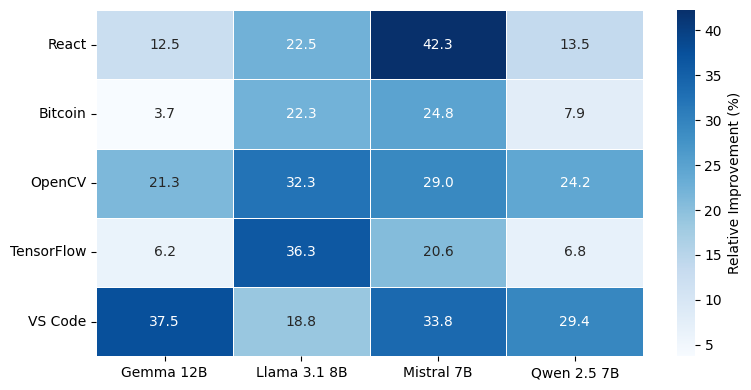

Saved heatmap to plots/stratified_selection/relative_improvement_heatmap.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = Path("../rqs/random_selection")

REPOS = [
    "facebook_react",
    "bitcoin_bitcoin",
    "opencv_opencv",
    "tensorflow_tensorflow",
    "microsoft_vscode",
]

MODELS = [
    "google/gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3",
    "Qwen/Qwen2.5-7B-Instruct",
]

MODEL_DISPLAY_NAMES = {
    "google/gemma-3-12b-it": "Gemma 12B",
    "meta-llama/Llama-3.1-8B-Instruct": "Llama 3.1 8B",
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral 7B",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen 2.5 7B",
}

REPO_DISPLAY_NAMES = {
    "facebook_react": "React",
    "bitcoin_bitcoin": "Bitcoin",
    "opencv_opencv": "OpenCV",
    "tensorflow_tensorflow": "TensorFlow",
    "microsoft_vscode": "VS Code",
}

F1_COL = "Macro_F1"
OUTPUT_PATH = "plots/stratified_selection/relative_improvement_heatmap.pdf"

# ============================================================
# LOAD DATA
# ============================================================

dfs = []

for repo in REPOS:
    for model in MODELS:
        provider, model_name = model.split("/", 1)

        csv_path = (
            BASE_DIR
            / repo
            / "models"
            / provider
            / model_name
            / "logs"
            / "fewshot_results_macro_f1.csv"
        )

        if not csv_path.exists():
            continue

        df = pd.read_csv(csv_path)
        df["Repo"] = repo
        df["Model"] = model
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# ============================================================
# COMPUTE RELATIVE IMPROVEMENT
# ============================================================

mean_df = (
    data
    .groupby(["Repo", "Model", "FewShot_Count"], as_index=False)
    .agg(mean_f1=(F1_COL, "mean"))
)

summary_df = (
    mean_df
    .groupby(["Repo", "Model"], as_index=False)
    .agg(
        min_f1=("mean_f1", "min"),
        max_f1=("mean_f1", "max"),
    )
)

summary_df["relative_improvement"] = (
    (summary_df["max_f1"] - summary_df["min_f1"])
    / summary_df["min_f1"]
) * 100

# ============================================================
# PIVOT
# ============================================================

heatmap_df = summary_df.pivot(
    index="Repo",
    columns="Model",
    values="relative_improvement"
)

heatmap_df = heatmap_df.reindex(REPOS)
heatmap_df = heatmap_df[MODELS]

# Rename axes for display
heatmap_df.index = [REPO_DISPLAY_NAMES[r] for r in heatmap_df.index]
heatmap_df.columns = [MODEL_DISPLAY_NAMES[m] for m in heatmap_df.columns]

# ============================================================
# SEABORN HEATMAP
# ============================================================

plt.figure(figsize=(8, 4))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Relative Improvement (%)"},
)

plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.savefig(OUTPUT_PATH, format="pdf", bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved heatmap to {OUTPUT_PATH}")

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import f1_score

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = Path("../rqs/random_selection")
ZERO_SHOT_BASE_DIR = Path("../rqs/zero_shot")
DATA_DIR = Path("../data")

OUTPUT_DIR = Path("plots/random_selection/mean_macro_f1_vs_k_by_repo")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEWSHOT_ORDER = [0, 1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32]

REPOS = [
    "facebook_react",
    "bitcoin_bitcoin",
    "opencv_opencv",
    "tensorflow_tensorflow",
    "microsoft_vscode",
]

MODELS = [
    "google/gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3",
    "Qwen/Qwen2.5-7B-Instruct",
]

# ============================================================
# MODEL DISPLAY NAMES
# ============================================================

model_display_name = {
    "google/gemma-3-12b-it": "Gemma-3-12B",
    "meta-llama/Llama-3.1-8B-Instruct": "Llama-3.1-8B",
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral-7B",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen-2.5-7B",
}

# ============================================================
# MODEL COLORS
# ============================================================

model_color_map = {
    "google/gemma-3-12b-it": "#1f77b4",
    "meta-llama/Llama-3.1-8B-Instruct": "#2ca02c",
    "mistralai/Mistral-7B-Instruct-v0.3": "#d62728",
    "Qwen/Qwen2.5-7B-Instruct": "#FFA737",
}

# ============================================================
# RANDOM GUESSER BASELINE
# ============================================================

def compute_uniform_baseline(repo):

    test_path = DATA_DIR / repo / f"{repo}_test_issues_normalized.json"

    with open(test_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    y_true = [item["labels"] for item in data]
    labels = sorted(list(set(y_true)))

    rng = np.random.default_rng(42)
    n_sim = 100

    f1s = []

    for _ in range(n_sim):
        y_random = rng.choice(labels, size=len(y_true))
        f1 = f1_score(
            y_true,
            y_random,
            labels=labels,
            average="macro",
            zero_division=0
        )
        f1s.append(f1)

    return np.mean(f1s) * 100


baseline_dict = {repo: compute_uniform_baseline(repo) for repo in REPOS}

# ============================================================
# LOAD ZERO-SHOT RESULTS
# ============================================================

zeroshot_dfs = []

for repo in REPOS:
    for model in MODELS:

        provider, model_name = model.split("/", 1)

        csv_path = (
            ZERO_SHOT_BASE_DIR
            / repo
            / provider
            / model_name
            / "logs"
            / "zero_shot_results_macro_f1.csv"
        )

        if not csv_path.exists():
            continue

        df = pd.read_csv(csv_path)
        df["Repo"] = repo
        df["Model"] = model
        df["FewShot_Count"] = 0

        zeroshot_dfs.append(df)

zeroshot_df = pd.concat(zeroshot_dfs, ignore_index=True)

# ============================================================
# LOAD FEW-SHOT RESULTS
# ============================================================

dfs = []

for repo in REPOS:
    for model in MODELS:

        provider, model_name = model.split("/", 1)

        csv_path = (
            BASE_DIR
            / repo
            / "models"
            / provider
            / model_name
            / "logs"
            / "fewshot_results_macro_f1.csv"
        )

        if not csv_path.exists():
            continue

        df = pd.read_csv(csv_path)
        df["Repo"] = repo
        df["Model"] = model

        dfs.append(df)

fewshot_df = pd.concat(dfs, ignore_index=True)

# ============================================================
# MERGE
# ============================================================

data = pd.concat([fewshot_df, zeroshot_df], ignore_index=True)

# ============================================================
# COMPUTE MEAN MACRO-F1
# ============================================================

stats_df = (
    data
    .groupby(["Repo", "Model", "FewShot_Count"], as_index=False)
    .agg(
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
    )
)

stats_df["mean_macro_f1"] *= 100
stats_df["std_macro_f1"] *= 100

# ============================================================
# PLOT (ONE FIGURE PER REPO)
# ============================================================

for repo in REPOS:

    fig, ax = plt.subplots(figsize=(10,5))

    repo_df_all = stats_df[stats_df["Repo"] == repo]

    for model in MODELS:

        model_df = (
            repo_df_all[repo_df_all["Model"] == model]
            .set_index("FewShot_Count")
            .reindex(FEWSHOT_ORDER)
            .reset_index()
        )
    
        mean = model_df["mean_macro_f1"]
        std = model_df["std_macro_f1"]
        x = model_df["FewShot_Count"]
    
        # Mean line
        ax.plot(
            x,
            mean,
            marker="o",
            linewidth=2,
            color=model_color_map[model],
            label=model_display_name[model],
        )
    
        # Shaded variation band (±1 std)
        ax.fill_between(
            x,
            mean - std,
            mean + std,
            color=model_color_map[model],
            alpha=0.15,
            linewidth=0
        )
    
        zero_row = model_df[model_df["FewShot_Count"] == 0]
    
        if not zero_row.empty:
            ax.scatter(
                0,
                zero_row["mean_macro_f1"].values[0],
                facecolors="white",
                edgecolors=model_color_map[model],
                s=90,
                zorder=5
            )

    # --------------------------------------------------------
    # Random baseline
    # --------------------------------------------------------

    ax.axhline(
        y=baseline_dict[repo],
        color="grey",
        linestyle="--",
        linewidth=1.5,
        label="Random guesser",
    )

    ax.set_xlabel("Few-Shot Count (k)")
    ax.set_ylabel("Mean Macro-F1 (%)")

    ax.set_xticks(FEWSHOT_ORDER)
    ax.set_ylim(0, 100)

    ax.grid(True, linestyle="--", alpha=0.4)

    ax.legend(loc="upper left", frameon=False)

    plt.tight_layout()

    output_path = OUTPUT_DIR / f"{repo}_mean_macro_f1_vs_k.pdf"
    plt.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close()

print("Plots saved to:", OUTPUT_DIR)

Plots saved to: plots\stratified_selection\mean_macro_f1_vs_k_by_repo


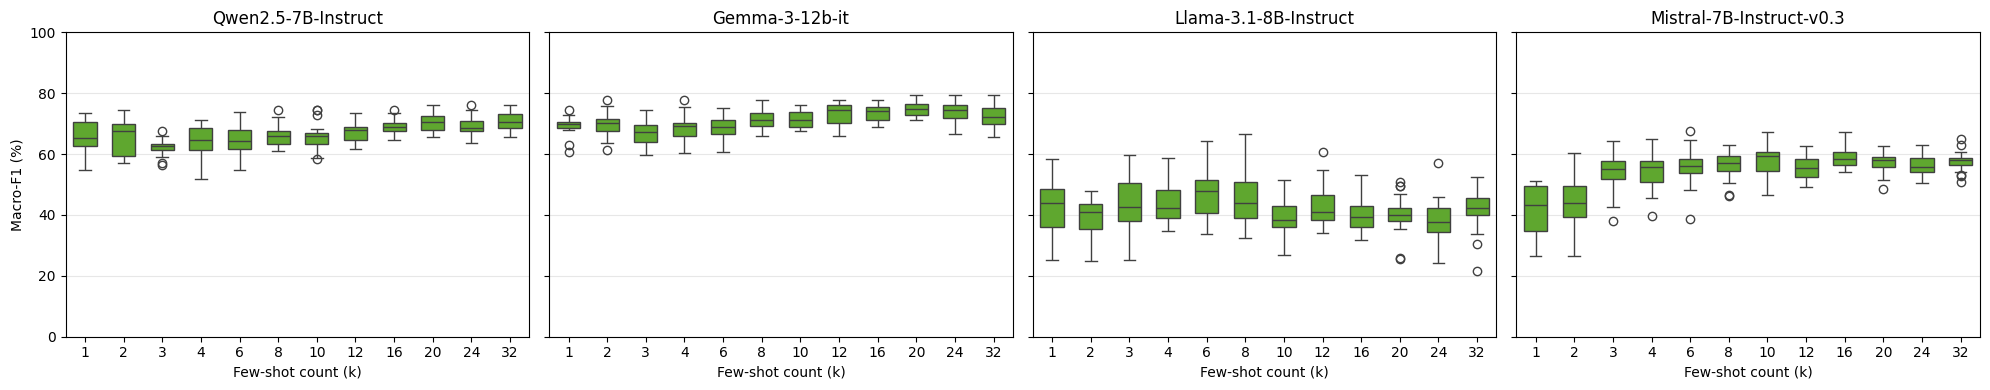

[SAVED] plots\stratified_selection\macro_f1_dist_vs_k_boxplots_by_model\facebook_react_macro_f1_dist_vs_k_boxplots_by_model.pdf


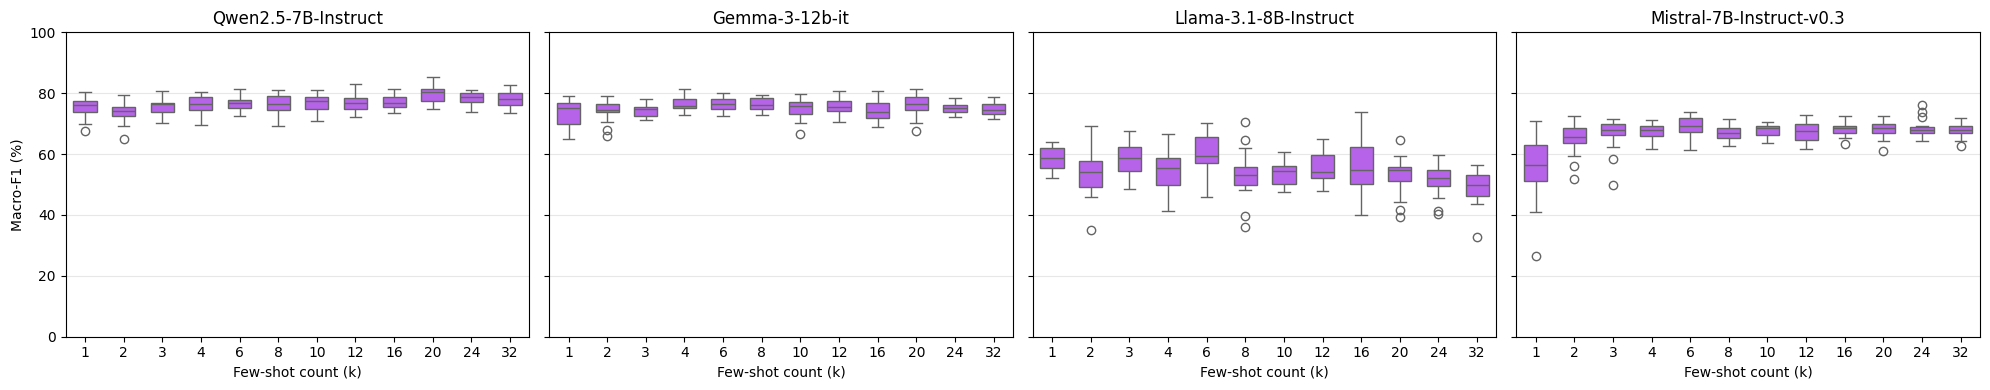

[SAVED] plots\stratified_selection\macro_f1_dist_vs_k_boxplots_by_model\bitcoin_bitcoin_macro_f1_dist_vs_k_boxplots_by_model.pdf


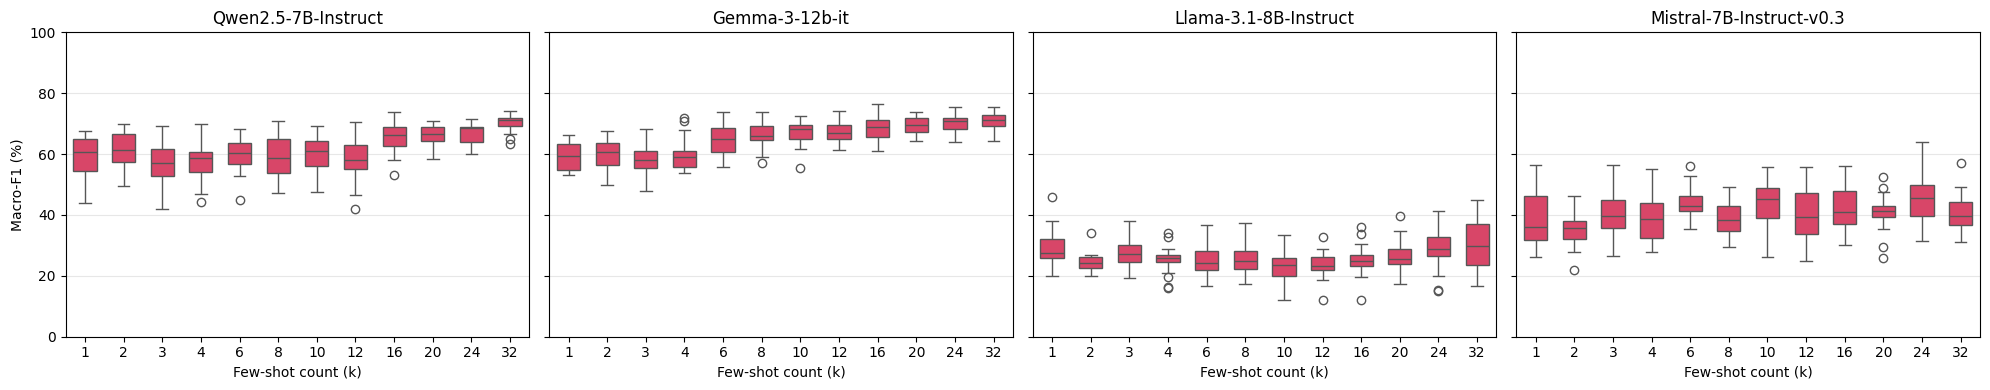

[SAVED] plots\stratified_selection\macro_f1_dist_vs_k_boxplots_by_model\opencv_opencv_macro_f1_dist_vs_k_boxplots_by_model.pdf


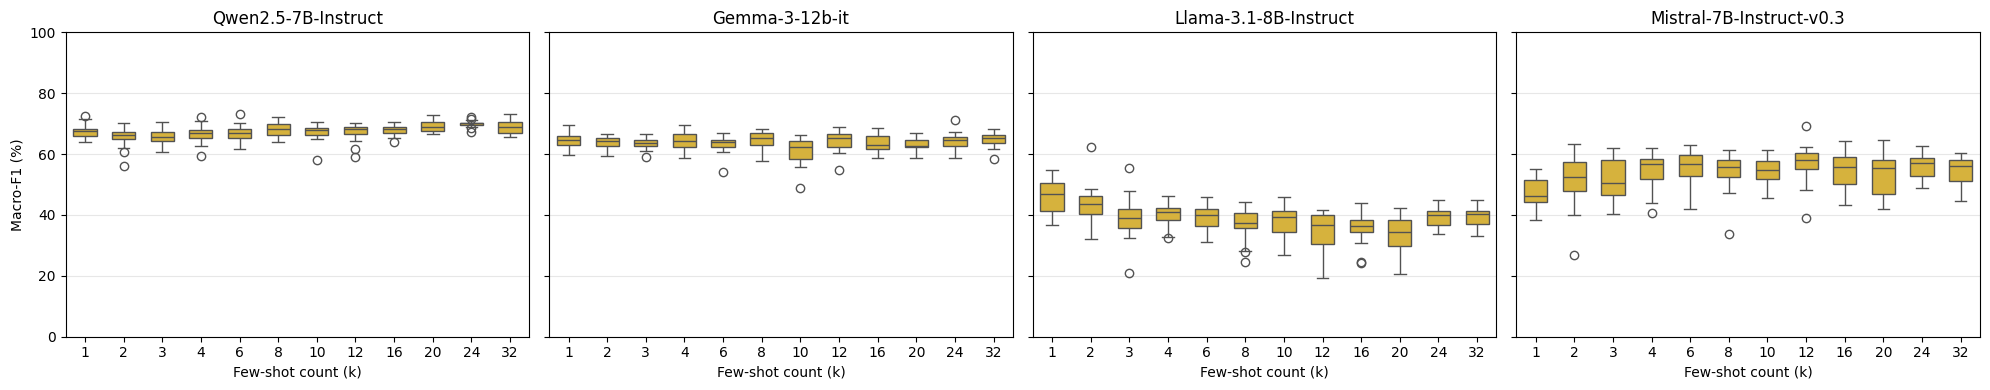

[SAVED] plots\stratified_selection\macro_f1_dist_vs_k_boxplots_by_model\tensorflow_tensorflow_macro_f1_dist_vs_k_boxplots_by_model.pdf


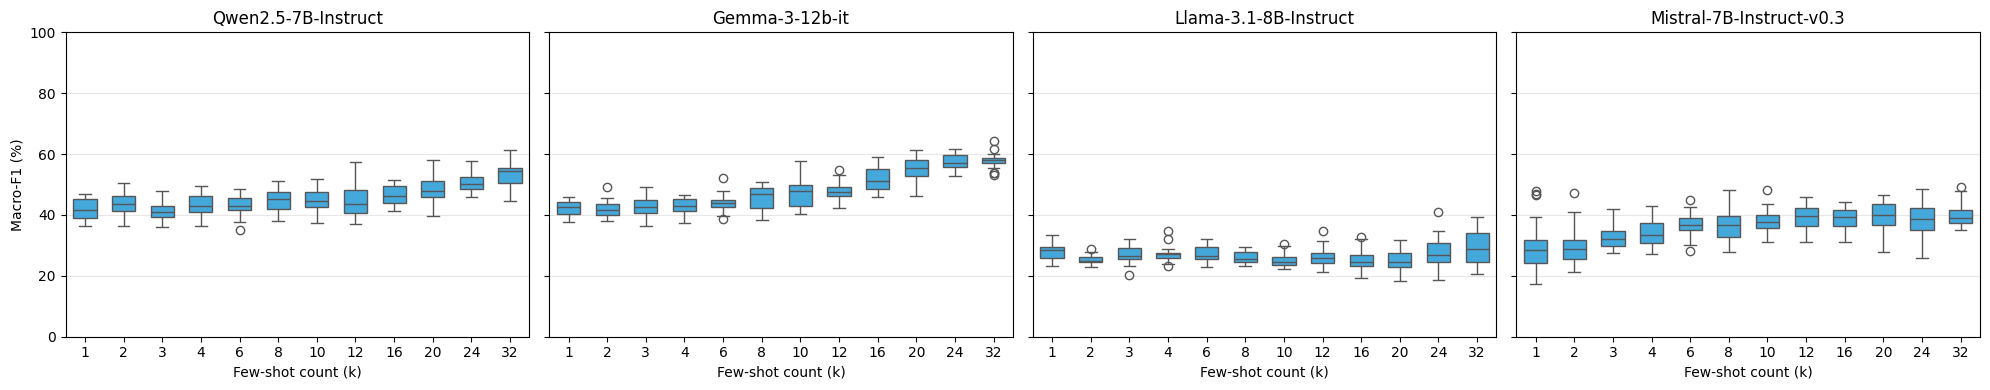

[SAVED] plots\stratified_selection\macro_f1_dist_vs_k_boxplots_by_model\microsoft_vscode_macro_f1_dist_vs_k_boxplots_by_model.pdf


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIGURATION
# ============================================================
BASE_DIR = Path("../rqs/random_selection")
FEW_SHOT_COUNTS = {1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32}

# ============================================================
# HELPERS
# ============================================================
def truncate_2(x):
    """
    Truncate to 2 decimal places without rounding.
    """
    return np.trunc(x * 100) / 100


# ============================================================
# LOAD ALL CSV FILES
# ============================================================
rows = []

for csv_path in BASE_DIR.glob("*/models/*/*/logs/fewshot_results_macro_f1.csv"):
    df = pd.read_csv(csv_path)

    repo = csv_path.parts[-6]
    provider = csv_path.parts[-4]
    model = csv_path.parts[-3]
    model_name = f"{provider}/{model}"

    df["Repo"] = repo
    df["Model"] = model_name

    rows.append(df)

if not rows:
    raise RuntimeError("No CSV files found. Check BASE_DIR path.")

all_df = pd.concat(rows, ignore_index=True)

# ============================================================
# FILTER & NORMALIZE
# ============================================================
all_df = all_df[all_df["FewShot_Count"].isin(FEW_SHOT_COUNTS)]

# Convert macro-f1 to percentage
all_df["Macro_F1_pct"] = all_df["macro_f1"] * 100.0

# ============================================================
# GLOBAL SUMMARY TABLE
# ============================================================
table_global = (
    all_df
    .groupby(["Repo", "Model"])
    .agg(
        Min_F1_pct=("Macro_F1_pct", "min"),
        Max_F1_pct=("Macro_F1_pct", "max"),
        Mean_F1_pct=("Macro_F1_pct", "mean"),
        Median_F1_pct=("Macro_F1_pct", "median"),
    )
    .reset_index()
)

table_global["Delta_F1_pct"] = (
    table_global["Max_F1_pct"] - table_global["Min_F1_pct"]
)

for col in [
    "Min_F1_pct",
    "Max_F1_pct",
    "Mean_F1_pct",
    "Median_F1_pct",
    "Delta_F1_pct",
]:
    table_global[col] = truncate_2(table_global[col])

table_global = table_global.sort_values(["Repo", "Model"])

# ============================================================
# PLOT CONFIG
# ============================================================
k_order = [1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32]

OUTPUT_DIR = Path("plots/random_selection/macro_f1_dist_vs_k_boxplots_by_model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

repo_color_map = {
    "facebook_react": "#5BBB1B",
    "bitcoin_bitcoin": "#BB4DFF",
    "opencv_opencv": "#F12D5B",
    "tensorflow_tensorflow": "#F0C023",
    "microsoft_vscode": "#2BB0F3",
}

model_name_map = {
    "google/gemma-3-12b-it": "Gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct": "Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral-7B-Instruct-v0.3",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen2.5-7B-Instruct",
}

REPOS = [
    "facebook_react",
    "bitcoin_bitcoin",
    "opencv_opencv",
    "tensorflow_tensorflow",
    "microsoft_vscode",
]

MODELS = [
    "Qwen/Qwen2.5-7B-Instruct",
    "google/gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3",
]

all_df = all_df[
    (all_df["Repo"].isin(REPOS)) &
    (all_df["Model"].isin(MODELS))
]

repos = REPOS
models = MODELS

# ============================================================
# PLOTTING
# ============================================================
for repo in repos:
    df_repo = all_df[all_df["Repo"] == repo].copy()

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(models),
        figsize=(5 * len(models), 4),
        sharey=True
    )

    repo_color = repo_color_map[repo]

    for ax, model in zip(axes, models):
        df_m = df_repo[df_repo["Model"] == model]

        sns.boxplot(
            data=df_m,
            x="FewShot_Count",
            y="Macro_F1_pct",
            ax=ax,
            color=repo_color,
            order=k_order,
            showfliers=True,
            width=0.6
        )

        display_name = model_name_map.get(model, model)

        ax.set_title(display_name)
        ax.set_xlabel("Few-shot count (k)")
        ax.grid(True, axis="y", alpha=0.3)

    axes[0].set_ylabel("Macro-F1 (%)")
    axes[0].set_ylim(0, 100)

    plt.tight_layout()

    output_path = OUTPUT_DIR / f"{repo}_macro_f1_dist_vs_k_boxplots_by_model.pdf"

    plt.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"[SAVED] {output_path}")

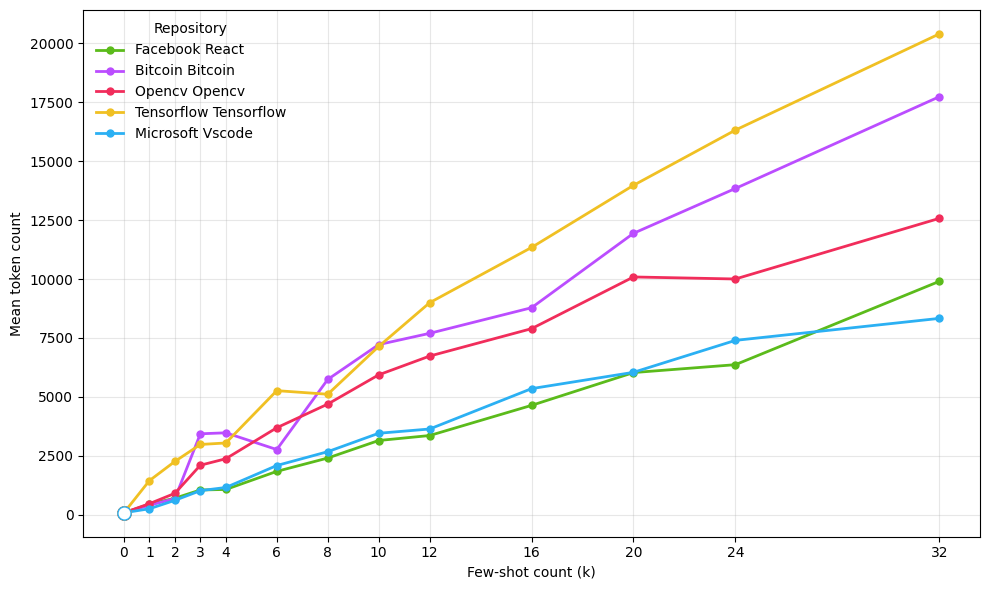

[SAVED] plots\stratified_selection\token_count_vs_k_by_model\token_count_vs_k_google_gemma-3-12b-it.pdf


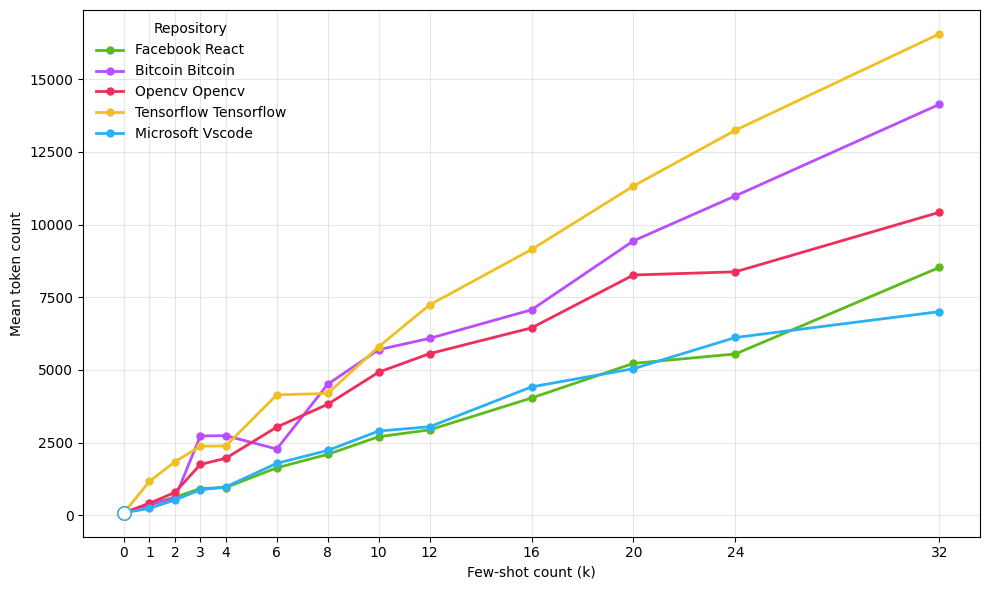

[SAVED] plots\stratified_selection\token_count_vs_k_by_model\token_count_vs_k_meta-llama_Llama-3.1-8B-Instruct.pdf


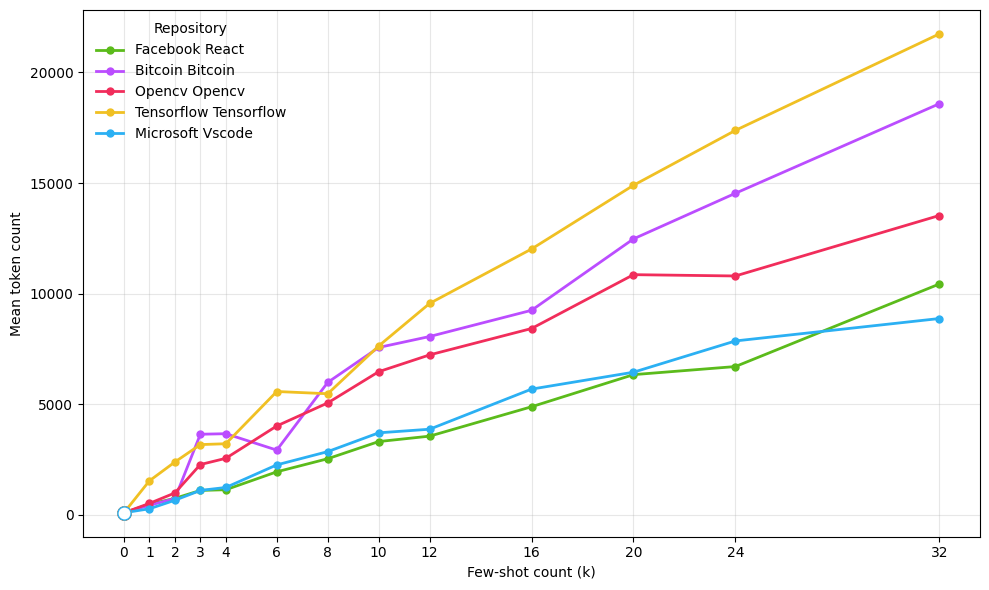

[SAVED] plots\stratified_selection\token_count_vs_k_by_model\token_count_vs_k_mistralai_Mistral-7B-Instruct-v0.3.pdf


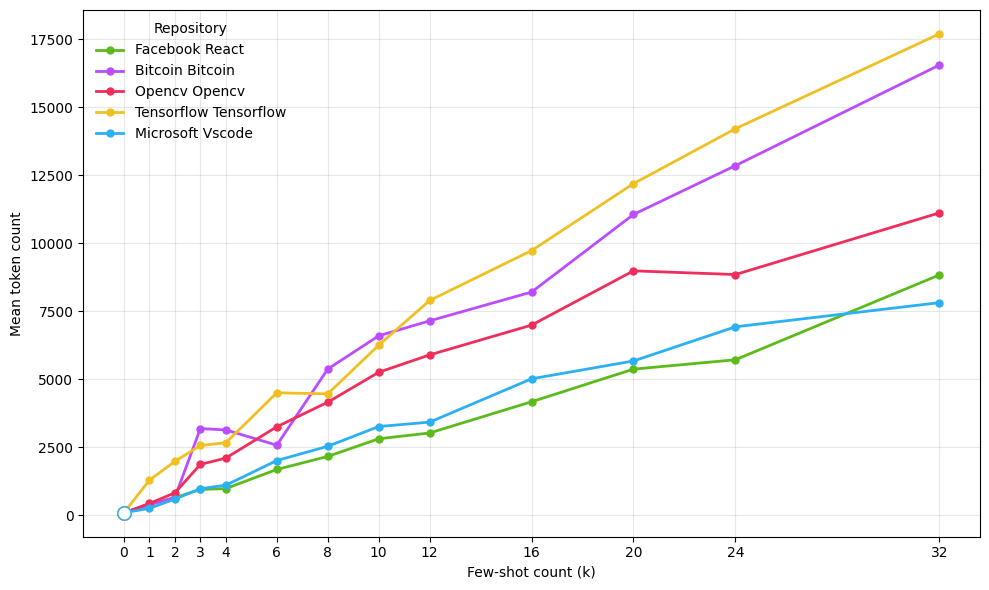

[SAVED] plots\stratified_selection\token_count_vs_k_by_model\token_count_vs_k_Qwen_Qwen2.5-7B-Instruct.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

STRAT_BASE = "../rqs/random_selection"
ZERO_BASE = "../rqs/zero_shot"

k_order = [0, 1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32]

OUTPUT_DIR = Path("plots/random_selection/token_count_vs_k_by_model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPOS = [
    "facebook_react",
    "bitcoin_bitcoin",
    "opencv_opencv",
    "tensorflow_tensorflow",
    "microsoft_vscode",
    
]

MODELS = [
    "google/gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3",
    "Qwen/Qwen2.5-7B-Instruct",
]

repo_color_map = {
    "facebook_react": "#5BBB1B",
    "bitcoin_bitcoin": "#BB4DFF",
    "opencv_opencv": "#F12D5B",
    "tensorflow_tensorflow": "#F0C023",
    "microsoft_vscode": "#2BB0F3",
}

TOKEN_COL = "Token_Count"

# ============================================================
# LOAD FEW-SHOT DATA
# ============================================================

fewshot_rows = []

for repo in REPOS:
    for model in MODELS:
        provider, model_name = model.split("/", 1)

        fewshot_path = Path(f"{STRAT_BASE}/{repo}/models/{provider}/{model_name}/logs/fewshot_results.csv")

        if not fewshot_path.exists():
            continue

        df = pd.read_csv(fewshot_path)

        if "Token_Count" not in df.columns or "FewShot_Count" not in df.columns:
            continue
        
        df = df[["FewShot_Count", "Token_Count"]].copy()
        df["Repo"] = repo
        df["Model"] = model

        fewshot_rows.append(df)

if fewshot_rows:
    fewshot_df = pd.concat(fewshot_rows, ignore_index=True)
else:
    fewshot_df = pd.DataFrame(columns=["Repo", "Model", "FewShot_Count", "Token_Count"])

# ============================================================
# LOAD ZERO-SHOT DATA
# ============================================================

zeroshot_rows = []

for repo in REPOS:
    for model in MODELS:

        provider, model_name = model.split("/", 1)

        zeroshot_path = Path(
            f"{ZERO_BASE}/{repo}/{provider}/{model_name}/logs/zeroshot_results.csv"
        )

        if not zeroshot_path.exists():
            continue

        df = pd.read_csv(
            zeroshot_path,
            header=None,
            names=[
                "Timestamp",
                "Repo",
                "FewShot_Count",
                "Prompt_Type",
                "Macro_F1",
                "Token_Count",
            ],
        )

        if "Token_Count" not in df.columns:
            continue

        df = df[["Token_Count"]].copy()
        df["Token_Count"] = pd.to_numeric(df["Token_Count"], errors="coerce")
        df["Repo"] = repo
        df["Model"] = model
        df["FewShot_Count"] = 0

        zeroshot_rows.append(df)

if zeroshot_rows:
    zeroshot_df = pd.concat(zeroshot_rows, ignore_index=True)
else:
    zeroshot_df = pd.DataFrame(columns=["Repo", "Model", "FewShot_Count", "Token_Count"])

# ============================================================
# MERGE DATA
# ============================================================

all_df = pd.concat([fewshot_df, zeroshot_df], ignore_index=True)

# Keep only desired k values
all_df = all_df[all_df["FewShot_Count"].isin(k_order)]

# ============================================================
# AGGREGATE
# ============================================================

token_means = (
    all_df
    .groupby(["Repo", "Model", "FewShot_Count"], as_index=False)
    .agg(mean_tokens=("Token_Count", "mean"))
)

token_means["FewShot_Count"] = pd.Categorical(
    token_means["FewShot_Count"],
    categories=k_order,
    ordered=True
)

# ============================================================
# PLOTTING: ONE FIGURE PER MODEL
# ============================================================

for model in MODELS:

    plt.figure(figsize=(10, 6))
    df_model = token_means[token_means["Model"] == model]

    for repo, color in repo_color_map.items():

        df_repo = df_model[df_model["Repo"] == repo]

        if df_repo.empty:
            continue

        plt.plot(
            df_repo["FewShot_Count"].astype(int),
            df_repo["mean_tokens"],
            marker="o",
            linewidth=2,
            markersize=5,
            color=color,
            label=repo.replace("_", " ").title()
        )

        # Highlight zero-shot
        zero_row = df_repo[df_repo["FewShot_Count"] == 0]
        if not zero_row.empty:
            plt.scatter(
                0,
                zero_row["mean_tokens"].values[0],
                facecolors="white",
                edgecolors=color,
                s=90,
                zorder=5
            )

    plt.xlabel("Few-shot count (k)")
    plt.ylabel("Mean token count")
    plt.grid(True, axis="both", alpha=0.3)

    plt.xticks(k_order)
    plt.legend(frameon=False, title="Repository")
    plt.tight_layout()

    out_path = OUTPUT_DIR / f"token_count_vs_k_{model.replace('/', '_')}.pdf"
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"[SAVED] {out_path}")

Zero-shot cl100k tokens: 84


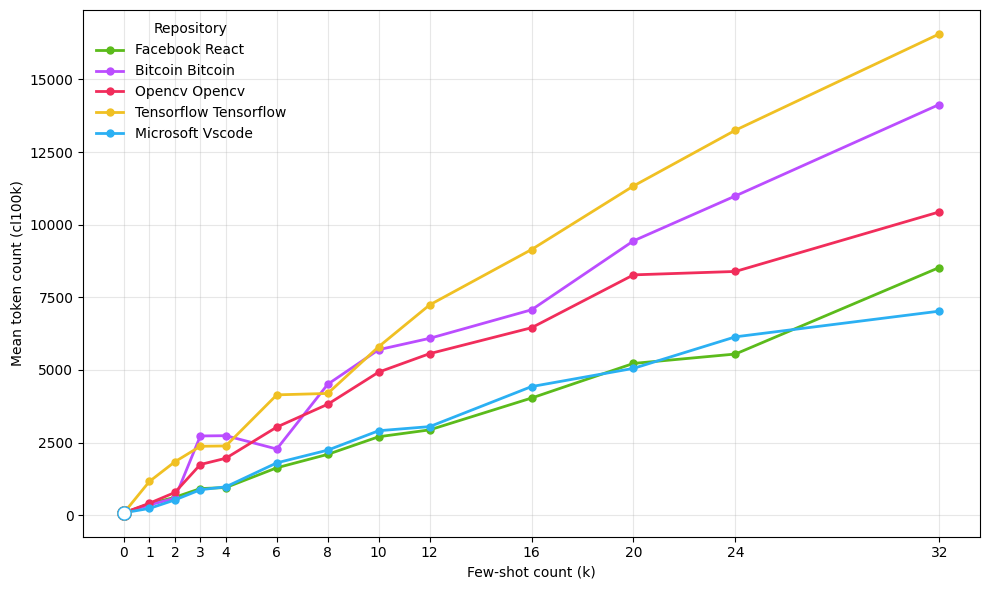

[SAVED] plots\stratified_selection\cl100k_token_count_vs_k\cl100k_token_count_vs_k.pdf


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

EXP_NUM    = "random_selection"
STRAT_BASE = Path("../rqs/random_selection")
ZERO_BASE  = Path("../rqs/zero_shot")

k_order = [0, 1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32]

OUTPUT_DIR = Path("plots/random_selection/cl100k_token_count_vs_k")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPOS = [
    "facebook_react",
    "bitcoin_bitcoin",
    "opencv_opencv",
    "tensorflow_tensorflow",
    "microsoft_vscode",
]

repo_color_map = {
    "facebook_react":        "#5BBB1B",
    "bitcoin_bitcoin":       "#BB4DFF",
    "opencv_opencv":         "#F12D5B",
    "tensorflow_tensorflow": "#F0C023",
    "microsoft_vscode":      "#2BB0F3",
}

# ============================================================
# LOAD ZERO-SHOT cl100k TOKEN COUNT (single shared value)
# ============================================================

zero_shot_file = ZERO_BASE / "cl100k_token_count_zero_shot.json"
with open(zero_shot_file, "r") as f:
    zero_shot_cl100k = json.load(f)["cl100k_tokens"]

print(f"Zero-shot cl100k tokens: {zero_shot_cl100k}")

# ============================================================
# LOAD FEW-SHOT cl100k TOKEN COUNTS
# ============================================================

rows = []

for repo in REPOS:
    cl100k_file = STRAT_BASE / repo / "cl100k_token_counts.json"

    if not cl100k_file.exists():
        print(f"[MISSING] {cl100k_file}")
        continue

    with open(cl100k_file, "r") as f:
        data = json.load(f)

    for k_str, trials in data.items():
        k = int(k_str)
        if k not in k_order:
            continue
        for trial in trials:
            rows.append({
                "Repo":          repo,
                "FewShot_Count": k,
                "cl100k_tokens": trial["cl100k_tokens"],
            })

    # Add zero-shot row for this repo (same value for all repos)
    rows.append({
        "Repo":          repo,
        "FewShot_Count": 0,
        "cl100k_tokens": zero_shot_cl100k,
    })

df = pd.DataFrame(rows)

# ============================================================
# AGGREGATE
# ============================================================

token_means = (
    df
    .groupby(["Repo", "FewShot_Count"], as_index=False)
    .agg(mean_tokens=("cl100k_tokens", "mean"))
)

# ============================================================
# PLOT — single panel (model-agnostic)
# ============================================================

plt.figure(figsize=(10, 6))

for repo, color in repo_color_map.items():
    df_repo = token_means[token_means["Repo"] == repo]
    if df_repo.empty:
        continue

    df_repo = df_repo.sort_values("FewShot_Count")

    plt.plot(
        df_repo["FewShot_Count"],
        df_repo["mean_tokens"],
        marker="o",
        linewidth=2,
        markersize=5,
        color=color,
        label=repo.replace("_", " ").title()
    )

    # Highlight zero-shot point
    zero_row = df_repo[df_repo["FewShot_Count"] == 0]
    if not zero_row.empty:
        plt.scatter(
            0,
            zero_row["mean_tokens"].values[0],
            facecolors="white",
            edgecolors=color,
            s=90,
            zorder=5
        )

plt.xlabel("Few-shot count (k)")
plt.ylabel("Mean token count (cl100k)")
plt.grid(True, axis="both", alpha=0.3)
plt.xticks(k_order)
plt.legend(frameon=False, title="Repository")
plt.tight_layout()

out_path = OUTPUT_DIR / "cl100k_token_count_vs_k.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
plt.close()
print(f"[SAVED] {out_path}")

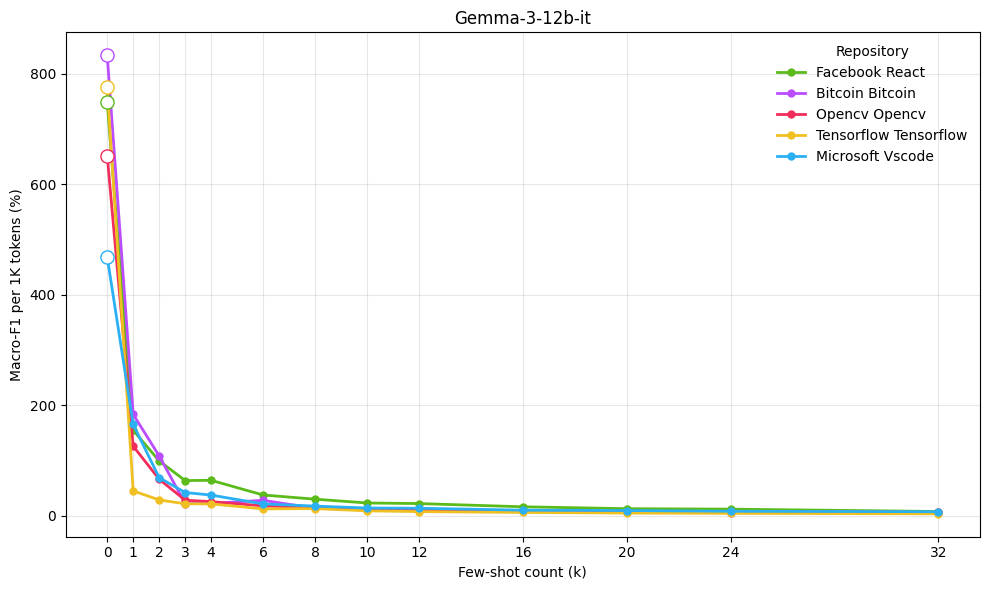

[SAVED] plots\stratified_selection\macro_f1_per_1k_tokens_by_model\macro_f1_per_1k_tokens_google_gemma-3-12b-it.pdf


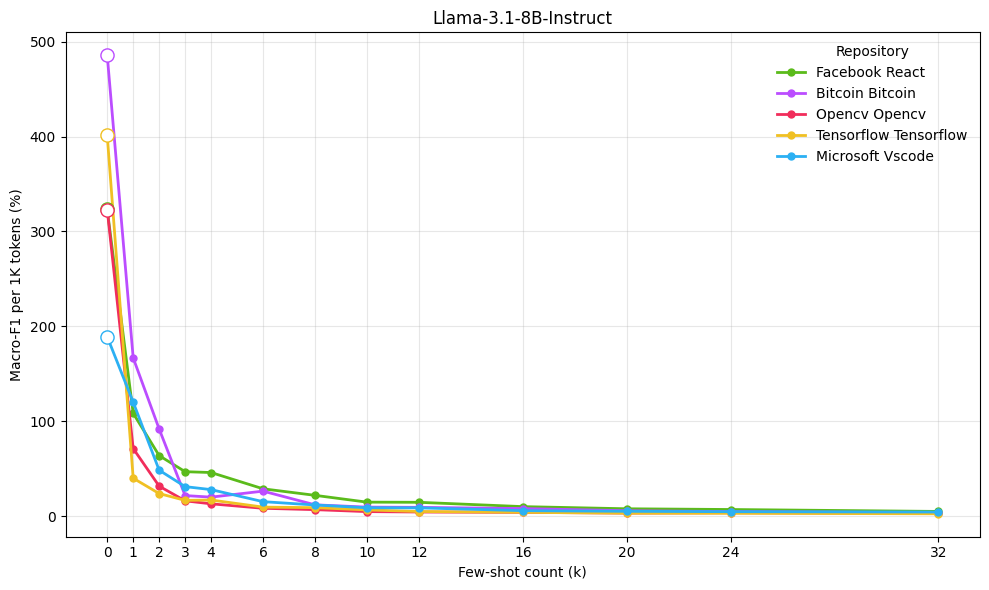

[SAVED] plots\stratified_selection\macro_f1_per_1k_tokens_by_model\macro_f1_per_1k_tokens_meta-llama_Llama-3.1-8B-Instruct.pdf


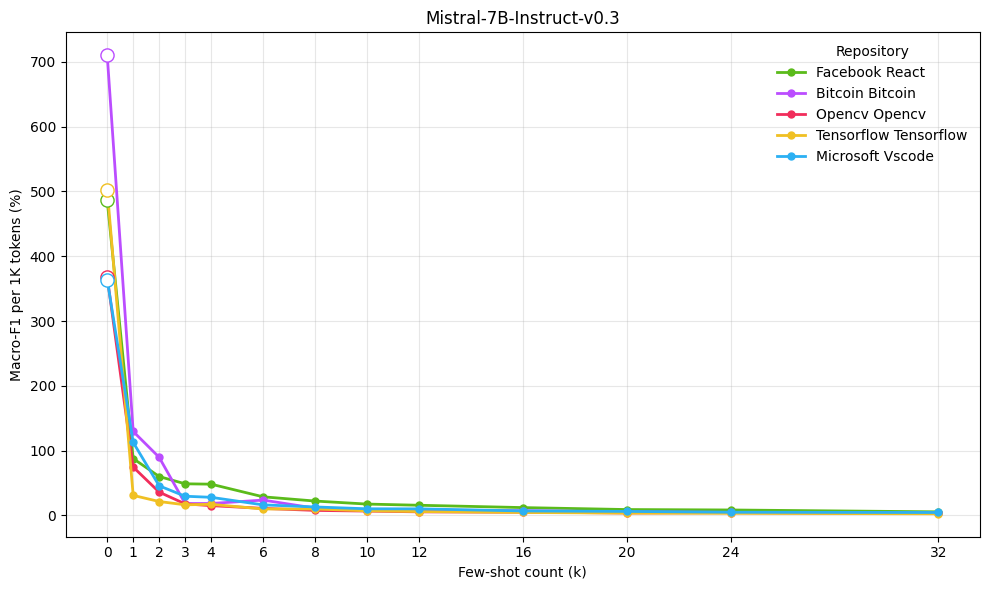

[SAVED] plots\stratified_selection\macro_f1_per_1k_tokens_by_model\macro_f1_per_1k_tokens_mistralai_Mistral-7B-Instruct-v0.3.pdf


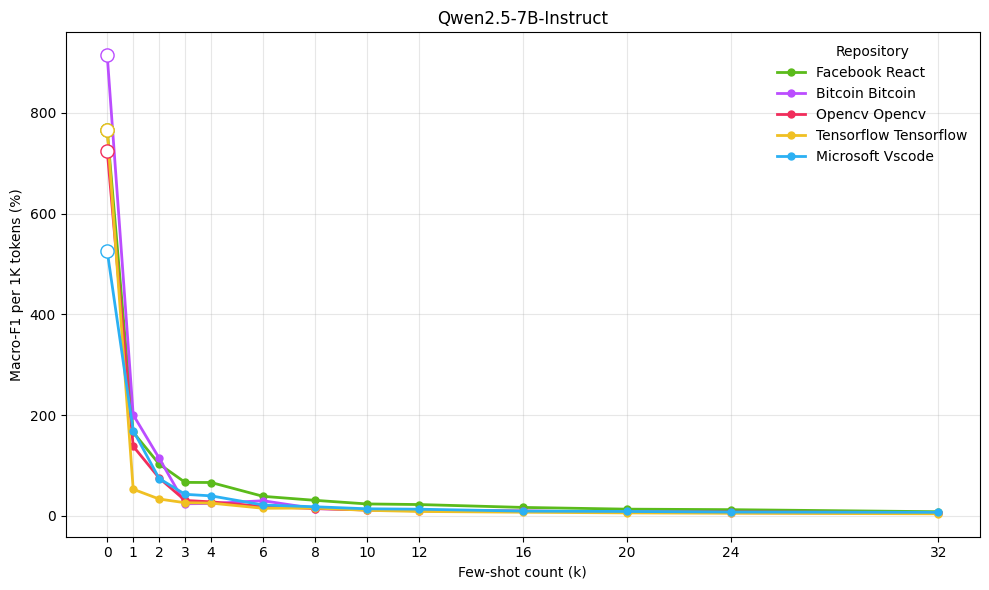

[SAVED] plots\stratified_selection\macro_f1_per_1k_tokens_by_model\macro_f1_per_1k_tokens_Qwen_Qwen2.5-7B-Instruct.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

STRAT_BASE = Path("../rqs/random_selection")
ZERO_BASE = Path("../rqs/zero_shot")

k_order = [0, 1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32]

REPOS = [
    "facebook_react",
    "bitcoin_bitcoin",
    "opencv_opencv",
    "tensorflow_tensorflow",
    "microsoft_vscode",
]

MODELS = [
    "google/gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3",
    "Qwen/Qwen2.5-7B-Instruct",
]

repo_color_map = {
    "facebook_react": "#5BBB1B",
    "bitcoin_bitcoin": "#BB4DFF",
    "opencv_opencv": "#F12D5B",
    "tensorflow_tensorflow": "#F0C023",
    "microsoft_vscode": "#2BB0F3",
}

model_name_map = {
    "google/gemma-3-12b-it": "Gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct": "Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral-7B-Instruct-v0.3",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen2.5-7B-Instruct",
}

TOKEN_COL = "Token_Count"
F1_COL = "macro_f1"

OUTPUT_DIR = Path("plots/random_selection/macro_f1_per_1k_tokens_by_model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD FEW-SHOT DATA
# ============================================================

fewshot_rows = []

for repo in REPOS:
    for model in MODELS:
        provider, model_name = model.split("/", 1)

        fewshot_path = (
            STRAT_BASE
            / repo
            / "models"
            / provider
            / model_name
            / "logs"
            / "fewshot_results_macro_f1.csv"
        )

        if not fewshot_path.exists():
            continue

        df = pd.read_csv(fewshot_path)

        if F1_COL not in df.columns or TOKEN_COL not in df.columns or "FewShot_Count" not in df.columns:
            continue

        df = df[["FewShot_Count", F1_COL, TOKEN_COL]].copy()
        df["Repo"] = repo
        df["Model"] = model

        fewshot_rows.append(df)

if fewshot_rows:
    fewshot_df = pd.concat(fewshot_rows, ignore_index=True)
else:
    fewshot_df = pd.DataFrame(columns=["Repo", "Model", "FewShot_Count", F1_COL, TOKEN_COL])

# ============================================================
# LOAD ZERO-SHOT DATA
# ============================================================

zeroshot_rows = []

for repo in REPOS:
    for model in MODELS:
        provider, model_name = model.split("/", 1)

        zeroshot_path = (
            ZERO_BASE
            / repo
            / provider
            / model_name
            / "logs"
            / "zero_shot_results_macro_f1.csv"
        )

        if not zeroshot_path.exists():
            continue

        df = pd.read_csv(zeroshot_path)

        if F1_COL not in df.columns or TOKEN_COL not in df.columns:
            continue

        df = df[[F1_COL, TOKEN_COL]].copy()
        df["Repo"] = repo
        df["Model"] = model
        df["FewShot_Count"] = 0

        zeroshot_rows.append(df)

if zeroshot_rows:
    zeroshot_df = pd.concat(zeroshot_rows, ignore_index=True)
else:
    zeroshot_df = pd.DataFrame(columns=["Repo", "Model", "FewShot_Count", F1_COL, TOKEN_COL])

# ============================================================
# MERGE DATA
# ============================================================

all_df = pd.concat([fewshot_df, zeroshot_df], ignore_index=True)
all_df = all_df[all_df["FewShot_Count"].isin(k_order)]

# ============================================================
# AGGREGATE
# ============================================================

agg = (
    all_df
    .groupby(["Repo", "Model", "FewShot_Count"], as_index=False)
    .agg(
        mean_f1=(F1_COL, "mean"),
        mean_tokens=(TOKEN_COL, "mean")
    )
)

agg["mean_f1_pct"] = agg["mean_f1"] * 100.0
agg["f1_per_1k_tokens"] = agg["mean_f1_pct"] / (agg["mean_tokens"] / 1000.0)

# ============================================================
# PLOTTING: ONE FIGURE PER MODEL
# ============================================================

for model in MODELS:

    plt.figure(figsize=(10, 6))
    df_m = agg[agg["Model"] == model]

    for repo, color in repo_color_map.items():

        df_r = df_m[df_m["Repo"] == repo]
        if df_r.empty:
            continue

        plt.plot(
            df_r["FewShot_Count"],
            df_r["f1_per_1k_tokens"],
            marker="o",
            linewidth=2,
            markersize=5,
            color=color,
            label=repo.replace("_", " ").title()
        )

        # Highlight zero-shot
        zero_row = df_r[df_r["FewShot_Count"] == 0]
        if not zero_row.empty:
            plt.scatter(
                0,
                zero_row["f1_per_1k_tokens"].values[0],
                facecolors="white",
                edgecolors=color,
                s=90,
                zorder=5
            )

    plt.xlabel("Few-shot count (k)")
    plt.ylabel("Macro-F1 per 1K tokens (%)")
    plt.grid(True, axis="both", alpha=0.3)
    plt.xticks(k_order)

    display_model = model_name_map.get(model, model)
    plt.title(display_model)

    plt.legend(title="Repository", frameon=False)
    plt.tight_layout()

    out = OUTPUT_DIR / f"macro_f1_per_1k_tokens_{model.replace('/', '_')}.pdf"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"[SAVED] {out}")

Zero-shot cl100k tokens: 84


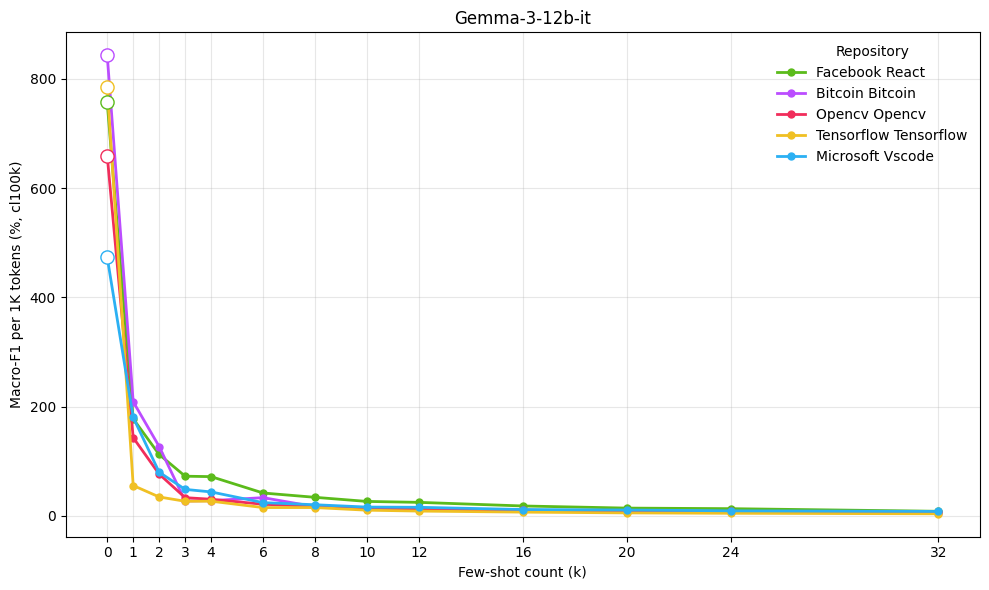

[SAVED] plots\stratified_selection\cl100k_macro_f1_per_1k_tokens_by_model\cl100k_macro_f1_per_1k_google_gemma-3-12b-it.pdf


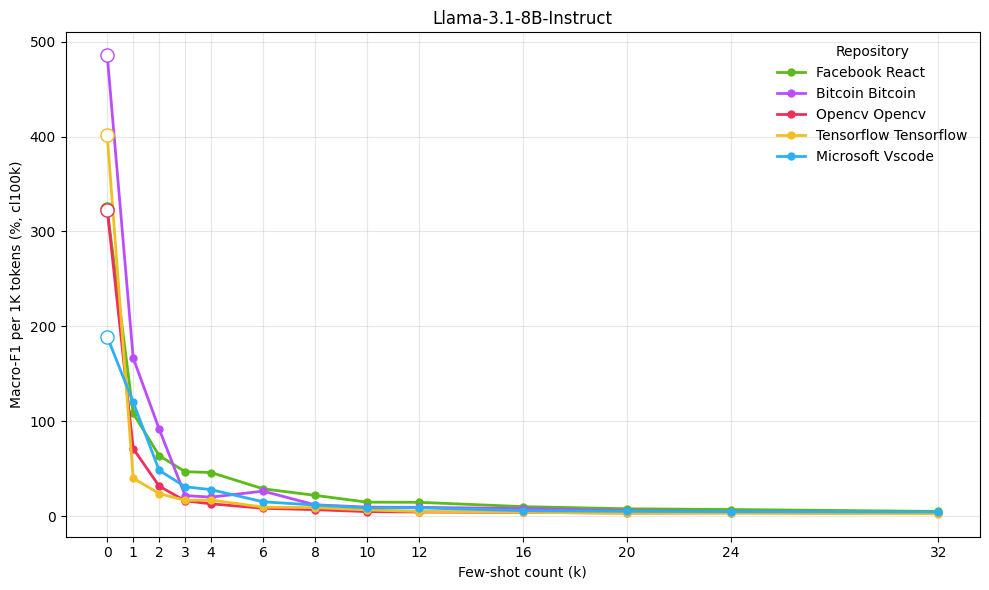

[SAVED] plots\stratified_selection\cl100k_macro_f1_per_1k_tokens_by_model\cl100k_macro_f1_per_1k_meta-llama_Llama-3.1-8B-Instruct.pdf


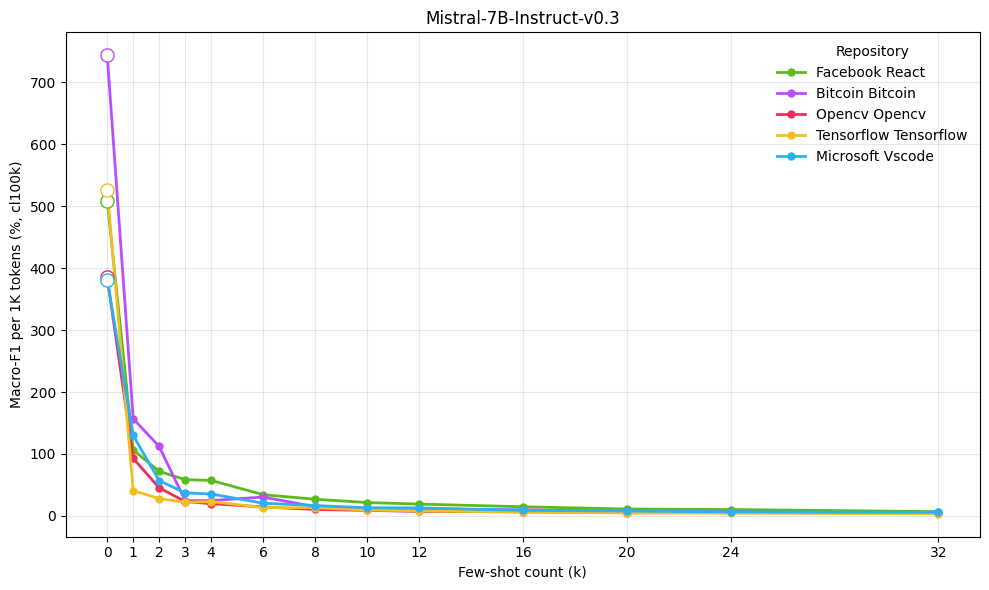

[SAVED] plots\stratified_selection\cl100k_macro_f1_per_1k_tokens_by_model\cl100k_macro_f1_per_1k_mistralai_Mistral-7B-Instruct-v0.3.pdf


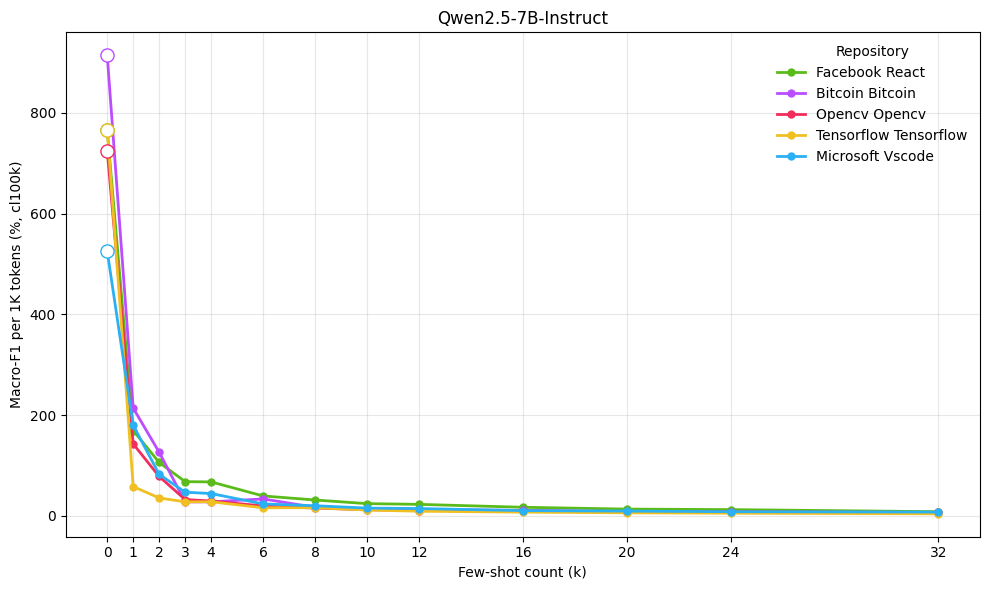

[SAVED] plots\stratified_selection\cl100k_macro_f1_per_1k_tokens_by_model\cl100k_macro_f1_per_1k_Qwen_Qwen2.5-7B-Instruct.pdf


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

STRAT_BASE = Path("../rqs/random_selection")
ZERO_BASE  = Path("../rqs/zero_shot")
EXP_NUM    = "random_selection"

k_order = [0, 1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32]

REPOS = [
    "facebook_react",
    "bitcoin_bitcoin",
    "opencv_opencv",
    "tensorflow_tensorflow",
    "microsoft_vscode",
]

MODELS = [
    "google/gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3",
    "Qwen/Qwen2.5-7B-Instruct",
]

repo_color_map = {
    "facebook_react":        "#5BBB1B",
    "bitcoin_bitcoin":       "#BB4DFF",
    "opencv_opencv":         "#F12D5B",
    "tensorflow_tensorflow": "#F0C023",
    "microsoft_vscode":      "#2BB0F3",
}

model_name_map = {
    "google/gemma-3-12b-it":              "Gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct":   "Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral-7B-Instruct-v0.3",
    "Qwen/Qwen2.5-7B-Instruct":           "Qwen2.5-7B-Instruct",
}

F1_COL = "Macro_F1"

OUTPUT_DIR = Path("plots/stratified_selection/cl100k_macro_f1_per_1k_tokens_by_model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD ZERO-SHOT cl100k TOKEN COUNT (single shared value)
# ============================================================

zero_shot_file = ZERO_BASE / "cl100k_token_count_zero_shot.json"
with open(zero_shot_file, "r") as f:
    zero_shot_cl100k = json.load(f)["cl100k_tokens"]

print(f"Zero-shot cl100k tokens: {zero_shot_cl100k}")

# ============================================================
# LOAD FEW-SHOT F1 DATA
# ============================================================

fewshot_rows = []

for repo in REPOS:
    for model in MODELS:
        provider, model_name = model.split("/", 1)
        fewshot_path = (
            STRAT_BASE / repo / "models" / provider / model_name
            / "logs" / "fewshot_results_macro_f1.csv"
        )
        if not fewshot_path.exists():
            continue
        df = pd.read_csv(fewshot_path)
        if F1_COL not in df.columns or "FewShot_Count" not in df.columns:
            continue
        df = df[["FewShot_Count", F1_COL]].copy()
        df["Repo"]  = repo
        df["Model"] = model
        fewshot_rows.append(df)

fewshot_df = pd.concat(fewshot_rows, ignore_index=True) if fewshot_rows else pd.DataFrame()
fewshot_df = fewshot_df[fewshot_df["FewShot_Count"].isin(k_order)]

# ============================================================
# LOAD ZERO-SHOT F1 DATA
# ============================================================

zeroshot_rows = []

for repo in REPOS:
    for model in MODELS:
        provider, model_name = model.split("/", 1)
        zeroshot_path = (
            ZERO_BASE / repo / provider / model_name
            / "logs" / "zero_shot_results_macro_f1.csv"
        )
        if not zeroshot_path.exists():
            continue
        df = pd.read_csv(zeroshot_path)
        if F1_COL not in df.columns:
            continue
        df = df[[F1_COL]].copy()
        df["FewShot_Count"] = 0
        df["Repo"]          = repo
        df["Model"]         = model
        zeroshot_rows.append(df)

zeroshot_df = pd.concat(zeroshot_rows, ignore_index=True) if zeroshot_rows else pd.DataFrame()

# ============================================================
# MERGE F1 DATA
# ============================================================

all_df = pd.concat([fewshot_df, zeroshot_df], ignore_index=True)
all_df = all_df[all_df["FewShot_Count"].isin(k_order)]

# ============================================================
# LOAD FEW-SHOT cl100k TOKEN COUNTS
# ============================================================

cl100k_rows = []

for repo in REPOS:
    cl100k_file = STRAT_BASE / repo / "cl100k_token_counts.json"
    if not cl100k_file.exists():
        print(f"[MISSING] {cl100k_file}")
        continue
    with open(cl100k_file, "r") as f:
        data = json.load(f)
    for k_str, trials in data.items():
        k = int(k_str)
        if k not in k_order:
            continue
        for trial in trials:
            cl100k_rows.append({
                "Repo":          repo,
                "FewShot_Count": k,
                "cl100k_tokens": trial["cl100k_tokens"],
            })

    # Add zero-shot row for this repo
    cl100k_rows.append({
        "Repo":          repo,
        "FewShot_Count": 0,
        "cl100k_tokens": zero_shot_cl100k,
    })

cl100k_df = pd.DataFrame(cl100k_rows)

# ============================================================
# AGGREGATE
# ============================================================

f1_means = (
    all_df
    .groupby(["Repo", "Model", "FewShot_Count"], as_index=False)
    .agg(mean_f1=(F1_COL, "mean"))
)

cl100k_means = (
    cl100k_df
    .groupby(["Repo", "FewShot_Count"], as_index=False)
    .agg(mean_cl100k=("cl100k_tokens", "mean"))
)

# Join — cl100k is model-agnostic so broadcast across models
agg = pd.merge(f1_means, cl100k_means, on=["Repo", "FewShot_Count"], how="left")

agg["mean_f1_pct"]      = agg["mean_f1"] * 100.0
agg["f1_per_1k_cl100k"] = agg["mean_f1_pct"] / (agg["mean_cl100k"] / 1000.0)

# ============================================================
# PLOTTING — one figure per model
# ============================================================

for model in MODELS:
    plt.figure(figsize=(10, 6))
    df_m = agg[agg["Model"] == model]

    for repo, color in repo_color_map.items():
        df_r = df_m[df_m["Repo"] == repo].sort_values("FewShot_Count")
        if df_r.empty:
            continue

        plt.plot(
            df_r["FewShot_Count"],
            df_r["f1_per_1k_cl100k"],
            marker="o",
            linewidth=2,
            markersize=5,
            color=color,
            label=repo.replace("_", " ").title()
        )

        # Highlight zero-shot point
        zero_row = df_r[df_r["FewShot_Count"] == 0]
        if not zero_row.empty:
            plt.scatter(
                0,
                zero_row["f1_per_1k_cl100k"].values[0],
                facecolors="white",
                edgecolors=color,
                s=90,
                zorder=5
            )

    plt.xlabel("Few-shot count (k)")
    plt.ylabel("Macro-F1 per 1K tokens (%, cl100k)")
    plt.grid(True, axis="both", alpha=0.3)
    plt.xticks(k_order)

    display_model = model_name_map.get(model, model)
    plt.title(display_model)

    plt.legend(title="Repository", frameon=False)
    plt.tight_layout()

    out = OUTPUT_DIR / f"cl100k_macro_f1_per_1k_{model.replace('/', '_')}.pdf"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"[SAVED] {out}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

LABELS = ["bug", "feature", "question"]

QUESTION = "question"
BUG = "bug"

ZERO_SHOT_DIR = Path("../rqs/zero_shot")
FEW_SHOT_DIR = Path("../rqs/random_selection")

OUTPUT_DIR = Path("./confusion_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

REPOS = [
    "facebook_react",
    "bitcoin_bitcoin",
    "opencv_opencv",
    "tensorflow_tensorflow",
    "microsoft_vscode",
]

MODELS = [
    "Qwen/Qwen2.5-7B-Instruct",
    "google/gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3",
]

# ============================================================
# DISPLAY NAMES
# ============================================================

model_display_name = {
    "google/gemma-3-12b-it": "Gemma-3-12B",
    "meta-llama/Llama-3.1-8B-Instruct": "Llama-3.1-8B",
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral-7B",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen-2.5-7B",
}

# ============================================================
# MODEL COLORS
# ============================================================

model_color_map = {
    "google/gemma-3-12b-it": "#1f77b4",
    "meta-llama/Llama-3.1-8B-Instruct": "#2ca02c",
    "mistralai/Mistral-7B-Instruct-v0.3": "#d62728",
    "Qwen/Qwen2.5-7B-Instruct": "#FFA737",
}

# ============================================================
# FEW-SHOT ORDER
# ============================================================

FEWSHOT_ORDER = [0, 1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32]

K_VALUES = [1,2,3,4,6,8,10,12,16,20,24,32]

N_TRIALS = 20


# ============================================================
# CONFUSION METRIC
# ============================================================

def q_to_bug_rate(df):
    questions = df[df["Ground_Truth"] == QUESTION]

    if len(questions) == 0:
        return None

    q_to_bug = questions[questions["Prediction"] == BUG]

    return len(q_to_bug) / len(questions)


# ============================================================
# LOAD ZERO SHOT
# ============================================================

rows = []

for repo in REPOS:
    for model in MODELS:

        provider, model_name = model.split("/", 1)

        pred_dir = (
            ZERO_SHOT_DIR
            / repo
            / provider
            / model_name
            / "logs"
            / "generations"
            / "zero_shot"
            / "run_0"
        )

        if not pred_dir.exists():
            continue

        trial_rates = []

        for file in pred_dir.glob("predictions_*.csv"):

            df = pd.read_csv(file)
            rate = q_to_bug_rate(df)

            if rate is not None:
                trial_rates.append(rate)

        if len(trial_rates) == 0:
            continue

        rows.append({
            "Repo": repo,
            "Model": model,
            "FewShot_Count": 0,
            "mean_confusion": np.mean(trial_rates),
            "std_confusion": np.std(trial_rates)
        })


# ============================================================
# LOAD FEW-SHOT RESULTS
# ============================================================

for repo in REPOS:
    for model in MODELS:

        provider, model_name = model.split("/", 1)

        for k in K_VALUES:

            trial_rates = []

            for trial in range(N_TRIALS):

                trial_dir = (
                    FEW_SHOT_DIR
                    / repo
                    / "models"
                    / provider
                    / model_name
                    / "logs"
                    / "generations"
                    / f"gen_fs_{k}_trial_{trial}"
                )

                if not trial_dir.exists():
                    continue

                for file in trial_dir.glob("predictions_*.csv"):

                    df = pd.read_csv(file)

                    rate = q_to_bug_rate(df)

                    if rate is not None:
                        trial_rates.append(rate)

            if len(trial_rates) == 0:
                continue

            rows.append({
                "Repo": repo,
                "Model": model,
                "FewShot_Count": k,
                "mean_confusion": np.mean(trial_rates),
                "std_confusion": np.std(trial_rates)
            })


# ============================================================
# DATAFRAME
# ============================================================

stats_df = pd.DataFrame(rows)


# ============================================================
# PLOT (ONE FIGURE PER REPO)
# ============================================================

for repo in REPOS:

    fig, ax = plt.subplots(figsize=(10,5))

    repo_df_all = stats_df[stats_df["Repo"] == repo]

    for model in MODELS:

        model_df = (
            repo_df_all[repo_df_all["Model"] == model]
            .set_index("FewShot_Count")
            .reindex(FEWSHOT_ORDER)
            .reset_index()
        )

        mean = model_df["mean_confusion"]
        std = model_df["std_confusion"]
        x = model_df["FewShot_Count"]

        # ----------------------------------------------------
        # Mean line
        # ----------------------------------------------------

        ax.plot(
            x,
            mean,
            marker="o",
            linewidth=2,
            color=model_color_map[model],
            label=model_display_name[model],
        )

        # ----------------------------------------------------
        # Variance band
        # ----------------------------------------------------

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            color=model_color_map[model],
            alpha=0.15,
            linewidth=0
        )

        # ----------------------------------------------------
        # Highlight zero-shot
        # ----------------------------------------------------

        zero_row = model_df[model_df["FewShot_Count"] == 0]

        if not zero_row.empty:
            ax.scatter(
                0,
                zero_row["mean_confusion"].values[0],
                facecolors="white",
                edgecolors=model_color_map[model],
                s=90,
                zorder=5
            )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    ax.set_xlabel("Few-Shot Count (k)")
    ax.set_ylabel("Question-Bug Confusion Rate")

    ax.set_xticks(FEWSHOT_ORDER)
    ax.set_ylim(0, 1)

    ax.grid(True, linestyle="--", alpha=0.4)

    ax.legend(loc="upper right", frameon=False)

    plt.tight_layout()

    output_path = OUTPUT_DIR / f"{repo}_q_to_bug_confusion_vs_k.pdf"

    plt.savefig(output_path, format="pdf", bbox_inches="tight")

    plt.close()

print("Plots saved to:", OUTPUT_DIR)

Plots saved to: confusion_analysis
